In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score, f1_score 

from sklearn.metrics import confusion_matrix
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("sentiment.csv",encoding='latin1',header=None)
df.columns = ['sentiment','id','date','query','user','tweet']

In [3]:
df.head()

,sentiment,id,date,query,user,tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
df

,sentiment,id,date,query,user,tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [5]:
print(df['sentiment'].value_counts())

sentiment
0    800000
4    800000
Name: count, dtype: int64


In [6]:
1.#Clean and preprocess raw tweet text by removing noise such as URLs, mentions, hashtags, and 
#special characters.

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['tweet'] = df['tweet'].apply(clean_text)

In [7]:
df.head()

,sentiment,id,date,query,user,tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,awww thats a bummer you shoulda got david ...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he cant update his facebook by t...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,i dived many times for the ball managed to sa...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,no its not behaving at all im mad why am i he...


In [8]:
2.#EDA proc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1600000 non-null  int64 
 1   id         1600000 non-null  int64 
 2   date       1600000 non-null  object
 3   query      1600000 non-null  object
 4   user       1600000 non-null  object
 5   tweet      1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [9]:
df.isnull().sum()

sentiment    0
id           0
date         0
query        0
user         0
tweet        0
dtype: int64

In [10]:
print("Rows, Columns:", df.shape)

Rows, Columns: (1600000, 6)


In [11]:
df['sentiment'].value_counts()

sentiment
0    800000
4    800000
Name: count, dtype: int64

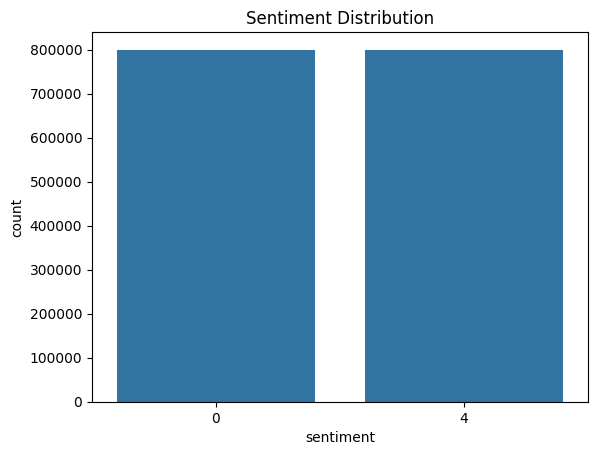

In [12]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [13]:
df['tweet_length'] = df['tweet'].apply(len)
df['tweet_length'].describe()

count    1.600000e+06
mean     6.392480e+01
std      3.413873e+01
min      1.000000e+00
25%      3.500000e+01
50%      5.900000e+01
75%      9.100000e+01
max      1.800000e+02
Name: tweet_length, dtype: float64

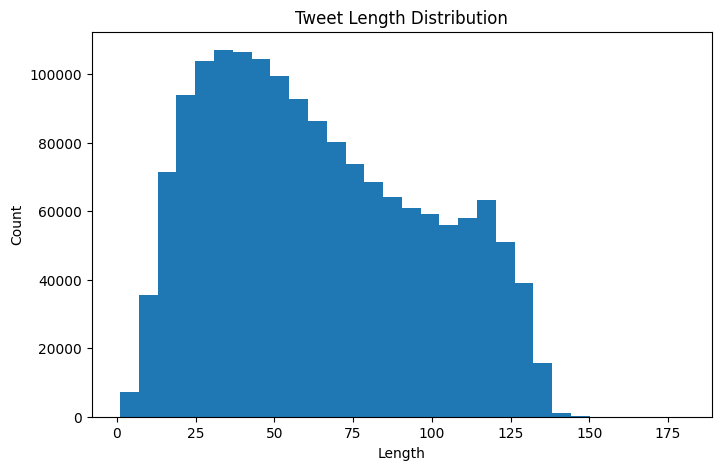

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['tweet_length'], bins=30)
plt.title("Tweet Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [15]:
all_words = ' '.join(df['tweet'])
words = all_words.split()
common_words = Counter(words).most_common(20)
print(common_words)

[('i', 751301), ('to', 564591), ('the', 520095), ('a', 378001), ('my', 314119), ('and', 298466), ('you', 270158), ('is', 236031), ('it', 230928), ('for', 215724), ('in', 214388), ('of', 183448), ('im', 178401), ('on', 167122), ('me', 160212), ('so', 150835), ('have', 144550), ('that', 141356), ('but', 127522), ('just', 125070)]


In [16]:
positive = df[df['sentiment']==1]
negative = df[df['sentiment']==0]
print("Positive Tweets:", len(positive))
print("Negative Tweets:", len(negative))

Positive Tweets: 0
Negative Tweets: 800000


In [17]:
3.#Feature Engineering

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['tweet'])
print(X.shape)

(1600000, 421395)


In [18]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['tweet'])
y = df['sentiment']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)    #train test split

In [20]:
print(y_train)

1374558    4
1389115    4
1137831    4
790714     0
1117911    4
          ..
259178     0
1414414    4
131932     0
671155     0
121958     0
Name: sentiment, Length: 1280000, dtype: int64


In [21]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14161838 stored elements and shape (1280000, 421395)>
  Coords	Values
  (0, 172825)	0.08510431322018176
  (0, 357477)	0.09929045844086341
  (0, 232770)	0.07805698765897429
  (0, 198172)	0.1156965706408125
  (0, 415983)	0.15770007237436567
  (0, 50914)	0.10117623649356487
  (0, 403448)	0.10446326900525933
  (0, 244716)	0.11084883629140022
  (0, 413184)	0.1746707203182191
  (0, 137551)	0.11177091247177312
  (0, 59379)	0.2548554012535761
  (0, 335531)	0.17743175066584108
  (0, 296521)	0.1642585160193665
  (0, 274213)	0.24944604180396374
  (0, 32687)	0.21448751286337614
  (0, 258732)	0.2538144603247372
  (0, 369880)	0.37983188417311653
  (0, 286373)	0.3529392856685997
  (0, 274700)	0.3529392856685997
  (0, 296575)	0.4155030551531849
  (1, 365297)	0.10020372307864796
  (1, 173617)	0.13622711833519635
  (1, 357938)	0.20686159274626942
  (1, 20968)	0.16542576649234494
  (1, 50914)	0.15810726659932042
  :	:
  (1279998, 351241)	0.249

In [22]:
print(y_test)

541200     0
750        0
766711     0
285055     0
705995     0
          ..
839535     4
1023175    4
1349377    4
1086942    4
158976     0
Name: sentiment, Length: 320000, dtype: int64


In [23]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3542586 stored elements and shape (320000, 421395)>
  Coords	Values
  (0, 249724)	0.49668304125051527
  (0, 418226)	0.3737012725791908
  (0, 159388)	0.4280865119286797
  (0, 6624)	0.6560451613353829
  (1, 123397)	0.16582198275452242
  (1, 232770)	0.14786454393699414
  (1, 241714)	0.22268336969882743
  (1, 149477)	0.18639688213851965
  (1, 72562)	0.3103261483385929
  (1, 17224)	0.46193609372644784
  (1, 375395)	0.3247941628553152
  (1, 296015)	0.6716613317852063
  (2, 255343)	0.13508542215554456
  (2, 198172)	0.13657655862256843
  (2, 174348)	0.12584230680054834
  (2, 363199)	0.14732829116073537
  (2, 149477)	0.11615611068043635
  (2, 181950)	0.120143046935288
  (2, 403448)	0.1233159609155183
  (2, 53044)	0.21164086839051996
  (2, 166479)	0.16621613248384304
  (2, 188523)	0.15044489516082848
  (2, 253873)	0.16748840542737653
  (2, 113872)	0.2149293266256502
  (2, 238685)	0.18404343551261768
  :	:
  (319996, 322664)	0.66967294

In [24]:
4.#model devlopment

model = LogisticRegression(max_iter = 500)
model.fit(X_train,y_train)                    #Logistic regression

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [25]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)         

In [26]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.79814375


In [27]:
nb = MultinomialNB()             #Naive Bayes
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.774590625


In [28]:
rf = RandomForestClassifier(n_estimators=5, max_depth=5, random_state=42,n_jobs=-1)          #Random Forest
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.516084375


In [29]:
5.#MOdel Evaluation
# Prediction
y_pred = model.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))            #Accuracy Score

Accuracy: 0.79814375


In [31]:
print(classification_report(y_test, y_pred))        #report

              precision    recall  f1-score   support

           0       0.81      0.78      0.79    159494
           4       0.79      0.81      0.80    160506

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



In [32]:
cm = confusion_matrix(y_test, y_pred)      #confusion matrix
print(cm)

[[124642  34852]
 [ 29742 130764]]


In [33]:
df['sentiment'].value_counts() 

sentiment
0    800000
4    800000
Name: count, dtype: int64

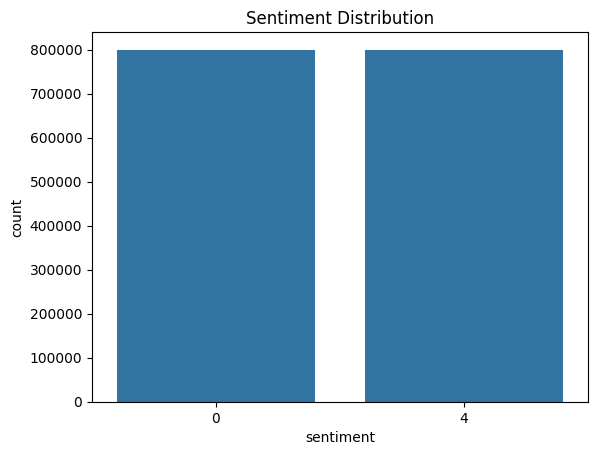

In [34]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [35]:
#Dataset is nearly balanced.

In [36]:
all_words = ' '.join(df['tweet'])
words = all_words.split()
common_words = Counter(words).most_common(100)
print(common_words)

[('i', 751301), ('to', 564591), ('the', 520095), ('a', 378001), ('my', 314119), ('and', 298466), ('you', 270158), ('is', 236031), ('it', 230928), ('for', 215724), ('in', 214388), ('of', 183448), ('im', 178401), ('on', 167122), ('me', 160212), ('so', 150835), ('have', 144550), ('that', 141356), ('but', 127522), ('just', 125070), ('with', 114881), ('be', 112586), ('at', 111320), ('its', 108595), ('not', 106390), ('was', 104089), ('this', 93025), ('now', 90413), ('good', 89424), ('up', 88541), ('day', 84818), ('get', 81603), ('all', 80720), ('out', 80540), ('like', 77781), ('are', 77701), ('no', 73934), ('go', 72982), ('dont', 67306), ('do', 66009), ('your', 65006), ('today', 64637), ('too', 64225), ('going', 64100), ('love', 63488), ('cant', 62893), ('work', 62823), ('got', 60903), ('am', 56507), ('time', 56127), ('from', 56012), ('back', 55991), ('lol', 55215), ('u', 53084), ('what', 52232), ('one', 52206), ('will', 51836), ('know', 51207), ('we', 50937), ('about', 50217), ('really', 49

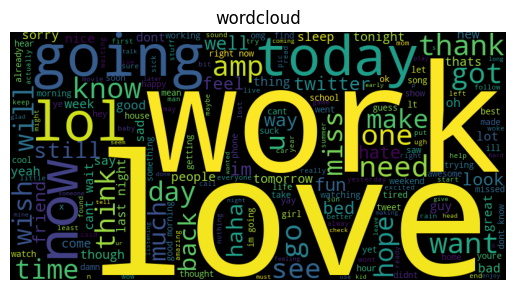

In [37]:
wordcloud = WordCloud(width=800,height=400).generate(all_words)
plt.imshow(wordcloud)
plt.title('wordcloud')
plt.axis('off')
plt.show()